# Configuration

In [1]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [2]:
from scipy.stats import norm

# estimators
from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Base example

In [4]:
num_obs = 1000  # number of observations
num_covariates = 10  # number of covariates

# generate covariates
relu_te_func = lambda x: np.maximum(x[:, 0], 0)  # true treatment effect function

def sample1(te_func: callable, sample_size: int, seed: int = None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # generate covariates
    X_arr = np.random.normal(size=(sample_size, num_covariates))  # Gaussian covariates with shape = (sample_size, num_covariates)
    W_arr = np.random.binomial(1, 0.5, size=(sample_size, ))  # binary treatment, shape = (sample_size, 1)

    Y_arr = te_func(X_arr) * W_arr + X_arr[:, 1] + np.maximum(X_arr[:, 2], 0) + np.random.normal(size=(sample_size, ))  # outcome, shape = (sample_size, 1)

    return X_arr, W_arr, Y_arr


In [7]:
cf = CausalForest()

In [23]:
def run_simple_causal_forest(X: np.ndarray, W: np.ndarray, Y: np.ndarray) -> CausalForest:
    # define causal forest
    cf = CausalForest()

    # fit causal forest to data set
    cf.fit(X=X, T=W, y=Y)

    # get CATE estimates
    # tau_pred = cf.oob_predict(X).flatten()  # (N, )

    return cf

def run_bootstrapped_causal_forest(
        X: np.ndarray, W: np.ndarray, Y: np.ndarray, num_bootstraps: int = 50, bootstrap_sample_size: int = 500
) -> list: 
    cf_list = [None for _ in range(num_bootstraps)]
    for i in range(num_bootstraps):
        # sample with replacement
        idx = np.random.choice(range(X.shape[0]), size=bootstrap_sample_size, replace=True)

        # fit causal forest to data set
        cf = CausalForest()
        cf.fit(X=X[idx], T=W[idx], y=Y[idx])

        # get CATE estimates
        # tau_pred = cf.predict(X).flatten()

        cf_list[i] = cf

    return cf_list 

def booststrap_cf_predict(cf_list: list, X: np.ndarray) -> np.ndarray:
    tau_pred = np.zeros((X.shape[0], len(cf_list)))
    for i, cf in enumerate(cf_list):
        tau_pred[:, i] = cf.predict(X).flatten()  # (N, num_bootstraps)

    return tau_pred.mean(axis=1)

In [60]:
te_func = relu_te_func   # true treatment effect function

# generate training set
X_arr, W_arr, Y_arr = sample1(te_func, num_obs, seed=123)

# generate test set
X_test_arr, W_test_arr, Y_test_arr = sample1(te_func, num_obs, seed=1234)

# fit simple causal forest
simple_cf = run_simple_causal_forest(X_arr, W_arr, Y_arr)

# fit bootstrapped causal forest
bootstrapped_cf_list = run_bootstrapped_causal_forest(X_arr, W_arr, Y_arr, num_bootstraps=100, bootstrap_sample_size=100)

In [61]:
simple_cf_pred = simple_cf.predict(X_test_arr).flatten()
bootstrapped_cf_pred = booststrap_cf_predict(bootstrapped_cf_list, X_test_arr)

# calculate rmse 
simple_cf_rmse = np.sqrt(np.mean((simple_cf_pred - te_func(X_test_arr))**2))
bootstrapped_cf_rmse = np.sqrt(np.mean((bootstrapped_cf_pred - te_func(X_test_arr))**2))

print(f"Simple causal forest RMSE: {simple_cf_rmse:.3f}")
print(f"Bootstrapped causal forest RMSE: {bootstrapped_cf_rmse:.3f}")

Simple causal forest RMSE: 0.558
Bootstrapped causal forest RMSE: 0.561


In [49]:
# # out of sample performance
# test_performance_df = pd.DataFrame({
#     'tau_pred': cf.predict(X_test_arr).flatten(),
#     'tau_true': te_func(X_test_arr)
# })
# # get estimator variance 
# _, tau_var = cf.predict_and_var(X_test_arr)
# tau_var = tau_var.flatten()
# # get confidence intervals
# alpha = 0.05
# phi = norm.ppf(1 - alpha / 2)
# test_performance_df.insert(2, 'tau_ci_lb', test_performance_df['tau_pred'] - phi * np.sqrt(tau_var))
# test_performance_df.insert(3, 'tau_ci_ub', test_performance_df['tau_pred'] + phi * np.sqrt(tau_var))
# test_performance_df.insert(4, 'is_significant', (test_performance_df['tau_ci_lb'] > 0) | (test_performance_df['tau_ci_ub'] < 0))

# # calculate performance metrics
# test_rmse = np.mean((test_performance_df['tau_pred'] - test_performance_df['tau_true']) ** 2) ** 0.5

# print(f'\nTest RMSE: {test_rmse:.2f}')
# print('Test set 95% significant coverage: {:.2%}\n'.format(test_performance_df['is_significant'].mean()))

In [57]:
# decision making
num_obs = 500
budget = 100
num_repeats = 100
clairvoyant_list = [None for _ in range(num_repeats)]
simple_cf_list = [None for _ in range(num_repeats)]
bootstrapped_cf_results_list = [None for _ in range(num_repeats)]

for i in tqdm(range(num_repeats)):
    X_arr, _, _ = sample1(te_func, num_obs)

    # get treatment effect and its variance
    simple_cf_pred = simple_cf.predict(X_arr).flatten()
    bootstrapped_cf_pred = booststrap_cf_predict(bootstrapped_cf_list, X_arr)

    te_true = te_func(X_arr)

    clairvoyant_list[i] = np.sort(te_true)[-budget:].sum()
    simple_cf_list[i] = te_true[np.argsort(-simple_cf_pred)[-budget:]].sum()
    bootstrapped_cf_results_list[i] = te_true[np.argsort(-bootstrapped_cf_pred)[-budget:]].sum()


result_df = pd.DataFrame({
    'clairvoyant': clairvoyant_list,
    'simple_cf': simple_cf_list,
    'bootstrapped_cf': bootstrapped_cf_results_list
})

100%|██████████| 100/100 [08:31<00:00,  5.12s/it]


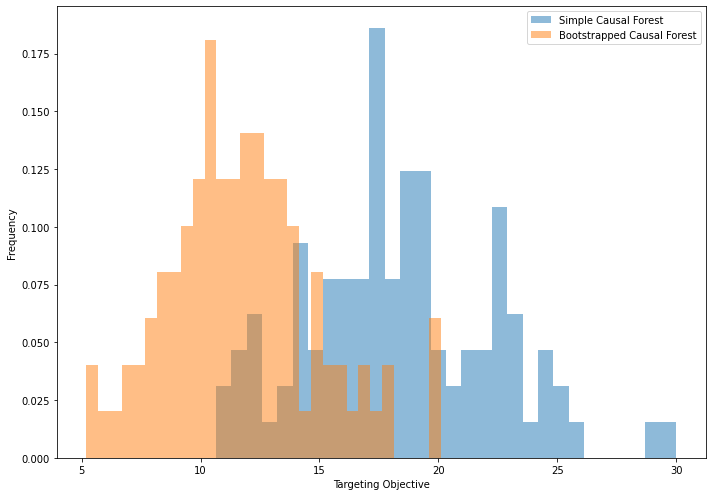

       clairvoyant   simple_cf  bootstrapped_cf
count   100.000000  100.000000       100.000000
mean    139.419937   18.349045        11.759167
std       7.776202    3.948283         3.108380
min     123.130524   10.651947         5.197210
25%     133.750931   15.714950         9.742195
50%     139.139384   17.908930        11.397118
75%     144.850101   21.097182        13.409753
max     162.356175   29.993898        20.117876


In [58]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.hist(simple_cf_list, bins=30, alpha=0.5, density=True, label='Simple Causal Forest')
ax.hist(bootstrapped_cf_results_list, bins=30, alpha=0.5, density=True, label='Bootstrapped Causal Forest')

ax.set_xlabel('Targeting Objective')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(result_df.describe())

In [201]:
# decision making
num_obs = 500
budget = 100
num_repeats = 1000
clairvoyant_list = [None for _ in range(num_repeats)]
cf_eto_list = [None for _ in range(num_repeats)]
cf_ucb_list = [None for _ in range(num_repeats)]
cf_lcb_list = [None for _ in range(num_repeats)]

for i in tqdm(range(num_repeats)):
    X_arr, _, _ = sample1(te_func, num_obs)

    # get treatment effect and its variance
    tau_pred, tau_var = cf.predict_and_var(X_arr)
    tau_pred, tau_var = tau_pred.flatten(), tau_var.flatten()
    te_true = te_func(X_arr)

    clairvoyant_list[i] = np.sort(te_true)[-budget:].sum()
    cf_eto_list[i] = te_true[np.argsort(-tau_pred)[-budget:]].sum()
    cf_ucb_list[i] = te_true[np.argsort(-tau_pred - phi * np.sqrt(tau_var))[-budget:]].sum()
    cf_lcb_list[i] = te_true[np.argsort(-tau_pred + phi * np.sqrt(tau_var))[-budget:]].sum()

    # print('Clairvoyant targeting objective: {:.2f}'.format(optimal_targeting_obj))
    # print('Causal forest targeting objective: {:.2f}'.format(cf_targeting_obj))
    # print('Causal forest UCB targeting objective: {:.2f}'.format(cf_ucb_targeting_obj))
    # print('Causal forest LCB targeting objective: {:.2f}'.format(cf_lcb_targeting_obj))

result_df = pd.DataFrame({
    'clairvoyant': clairvoyant_list,
    'cf_eto': cf_eto_list,
    'cf_ucb': cf_ucb_list,
    'cf_lcb': cf_lcb_list
})

100%|██████████| 1000/1000 [00:28<00:00, 35.16it/s]


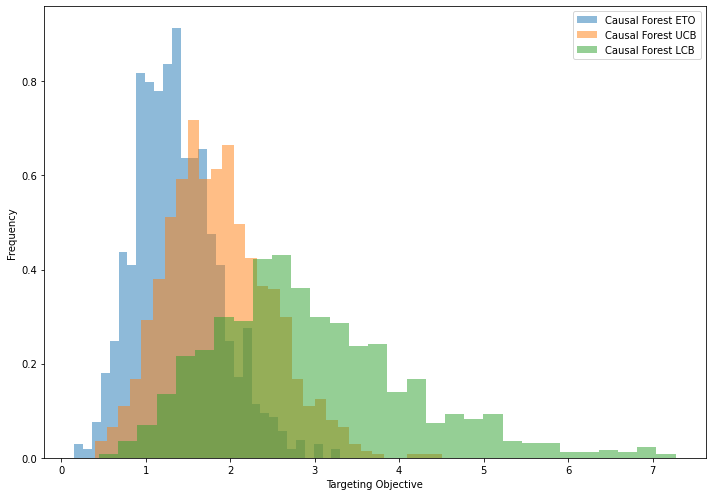

       clairvoyant       cf_eto       cf_ucb       cf_lcb
count  1000.000000  1000.000000  1000.000000  1000.000000
mean    139.379523     1.368142     1.860308     2.938873
std       6.685054     0.491099     0.617734     1.176311
min     117.058721     0.151563     0.401795     0.446441
25%     134.951475     1.007272     1.422300     2.122586
50%     139.328476     1.326126     1.801165     2.761687
75%     143.869133     1.672776     2.264391     3.615344
max     163.258637     3.303753     4.502586     7.272281


In [204]:
fig, ax = plt.subplots(figsize=(10, 7))

# ax.hist(clairvoyant_list, bins=30, alpha=0.5, label='Clairvoyant')
ax.hist(cf_eto_list, bins=30, alpha=0.5, density=True, label='Causal Forest ETO')
ax.hist(cf_ucb_list, bins=30, alpha=0.5, density=True, label='Causal Forest UCB')
ax.hist(cf_lcb_list, bins=30, alpha=0.5, density=True, label='Causal Forest LCB')

ax.set_xlabel('Targeting Objective')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print(result_df.describe())

# Group targeting

## Case 1

There are $K$ customers, each with $N$ observations. The DGP is the simplest possible: no individual characteristics needed. binary. 

$$
\begin{aligned}
Y_{ki} & = \tau_k T_i + \mathcal{N}(0, \sigma_Y^2) \\ 
T_{i} & \sim B(0.5)
\end{aligned}
$$

In [115]:
""" 
Data Generation Process
"""
random.seed = 1
np.random.seed(1)

num_cust = 5  # number of customers (or customer clusters)
num_obs = 10  # number of observations for each customers

# generate true treatment effect
te_arr = np.random.uniform(-1, 1, size=(num_cust, ))  # (num_cust, ): treatment effect for each customers (HTE)

# binary
treatment_arr = np.random.binomial(1, 0.5, size=(num_cust, num_obs))  # (num_cust, num_obs)

# generate outcome based on treatment and treatment effect
outcome_arr = treatment_arr * np.repeat(te_arr.reshape(-1, 1), num_obs, axis=1) + np.random.normal(0, 0.01, size=(num_cust, num_obs))  # (num_cust, num_obs)

In [116]:
"""
Estimation
"""

# estimate treatment effect
te_estimate_arr = np.zeros(shape=(num_cust, ))
for k in range(num_cust):
    ols = OLS(endog=outcome_arr[k].flatten(), exog=treatment_arr[k].flatten()).fit()
    te_estimate_arr[k] = ols.params[0]

# estimation result analysis
result = pd.DataFrame({
    'True TE': te_arr, 'Estimated TE': te_estimate_arr
})

result

,True TE,Estimated TE
0,-0.165956,-0.164286
1,0.440649,0.445622
2,-0.999771,-0.998726
3,-0.395335,-0.397468
4,-0.706488,-0.705123


In [117]:
""" 
Targeting 
"""
capacity = 2  # out of the K customers, how many are we targeting 

estimated_targeting_arr = np.argsort(-te_estimate_arr)[:capacity]  # selected customers based on estimated treatment effect
true_targeting_arr = np.argsort(-te_arr)[:capacity]  # selected customers based on true treatment effect

true_targeting_value = te_arr[true_targeting_arr].sum()
estimated_targeting_value = te_estimate_arr[estimated_targeting_arr].sum()
true_estimated_targeting_value = te_arr[estimated_targeting_arr].sum()

print(f'Estimated targeting value = {estimated_targeting_value:.4f}')
print(f'True value of targeting based on estimation = {true_estimated_targeting_value:.4f}')
print(f'Best targeting value achievable = {true_targeting_value:.4f}')

Estimated targeting value = 0.2813
True value of targeting based on estimation = 0.2747
Best targeting value achievable = 0.2747


## Case 2

There are $K$ customers group, each with $N$ observations. In this case the researchers observe individual characteristics $\vec{X}_k\in \mathcal{X}\subset\mathbb{R}^D$. The heterogeneous treatment effect is a $\mathcal{X}$-measurable function $\tau: \mathcal{X} \mapsto \mathbb{R}$. The DGP is the following: 
$$
\begin{aligned}
Y_{ki} & = \tau(\vec{X}_k) T_{ki} + \mathcal{N}(0, \sigma_Y^2) \\
T_{ki} & \sim B(p) \\ 
\vec{X}_k & \sim \mathcal{N}(\vec{\mu}_k, \text{diag}(\vec{\sigma}_k^2)),\;\quad \forall\; k \\ 
\vec{\mu}_k & \sim U[-1, 1]^D,\;\quad \forall\; k \\ 
\vec{\sigma}_k & \sim U[0, 1]^D,\;\quad \forall\; k
\end{aligned}
$$

In [4]:
""" 
Data Generation Process
"""
num_cust = 5  # number of customers (or customer clusters)
num_obs = 10  # number of observations for each customers
feat_dim = 10  # number of features for each indivdiual

# generate individual characteristics
sigma_arr = np.random.uniform(0, 1, size=(num_cust, feat_dim))  # (num_cust, feat_dim): standard deviation of each feature for each customer
mu_arr = np.random.uniform(-1, 1, size=(num_cust, feat_dim))  # (num_cust, feat_dim): mean of each feature for each customer
X_arr = np.array([
    np.random.multivariate_normal(mu_arr[i], np.diag(sigma_arr[i])) for i in range(num_cust)
])  # (num_cust, feat_dim): individual characteristics

# generate true treatment effect
te_func = lambda x_arr: np.maximum(x_arr[:, 0], 0).reshape(-1, 1)  # true treatment effect function
te_arr = te_func(X_arr)  # (num_cust, 1)

# generate treatment variables
treatment_arr = np.random.binomial(1, 0.5, size=(num_cust, num_obs))  # (num_cust, num_obs)

# generate outcome variables
outcome_arr = np.repeat(te_arr, num_obs, axis=1) * treatment_arr + np.random.normal(0, 0.1, size=(num_cust, num_obs))  # (num_cust, num_obs)

In [85]:
"""
Estimation
"""

# define causal forest
cf = CausalForest()

# prepare data
train_treatment_arr = treatment_arr.flatten().reshape(-1, 1)  # (num_cust, num_obs) -> (num_cust * num_obs, 1)
train_outcome_arr = outcome_arr.flatten().reshape(-1, 1)  # (num_cust, num_obs) -> (num_cust * num_obs, 1)
train_X_arr = np.concatenate([
    np.repeat(X_arr[k].reshape((1, feat_dim)), repeats=num_obs, axis=0)
    for k in range(X_arr.shape[0])
], axis=0)  # (num_cust, feat_dim) -> (num_cust * num_obs, feat_dim)

# fit causal forest to data set
cf.fit(X=train_X_arr, T=train_treatment_arr, y=train_outcome_arr)

te_est_arr = cf.oob_predict(Xtrain=train_X_arr).reshape((num_cust, num_obs))  # (num_cust, num_obs)
te_est_arr = np.mean(te_est_arr, axis=1)  # (num_cust)

result = pd.DataFrame({
    'True TE': te_arr.flatten(), 
    'Estimated TE': te_est_arr
})

result

,True TE,Estimated TE
0,0.084562,0.185922
1,0.569002,0.276917
2,0.000000,0.133024
3,0.117035,0.174036
4,0.000000,0.116019


In [82]:
""" 
Targeting 
"""
capacity = 2  # out of the K customers, how many are we targeting 

est_targeting_arr = np.argsort(-te_est_arr)[:capacity]  # selected customers based on estimated treatment effect
true_targeting_arr = np.argsort(-te_arr.flatten())[:capacity]  # selected customers based on true treatment effect

true_targeting_value = te_arr[true_targeting_arr].sum()
est_targeting_value = te_est_arr[est_targeting_arr].sum()
true_est_targeting_value = te_arr[est_targeting_arr].sum()

print('Clairvoyant targeting: ', np.sort(true_targeting_arr))
print('Targeting based on estimated CATE: ', np.sort(est_targeting_arr), '\n')

print(f'Estimated targeting value = {est_targeting_value:.4f}')
print(f'True value of targeting based on estimation = {true_est_targeting_value:.4f}')
print(f'Best targeting value achievable = {true_targeting_value:.4f}')

Clairvoyant targeting:  [1 3]
Targeting based on estimated CATE:  [0 1] 

Estimated targeting value = 0.3878
True value of targeting based on estimation = 0.6536
Best targeting value achievable = 0.6860
